In [1]:
from pyforest import*
from pandas_datareader import data 
import matplotlib.pyplot as plt
import pandas as pd
import datetime
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv("AIML Dataset.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [3]:
df['isFraud'].isnull().sum()

np.int64(0)

In [4]:
df['isFlaggedFraud'].isnull().sum()

np.int64(0)

In [5]:
df['amount']=df['amount'].astype(int)
df['amount']


0             9839
1             1864
2              181
3              181
4            11668
            ...   
6362615     339682
6362616    6311409
6362617    6311409
6362618     850002
6362619     850002
Name: amount, Length: 6362620, dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          int64  
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(4), int64(4), object(3)
memory usage: 534.0+ MB


In [7]:
df['balanceDifferOrig']=df['oldbalanceOrg']-df['newbalanceOrig']
df['balanceDifferDest']=df['newbalanceDest']-df['oldbalanceDest']
(df['balanceDifferOrig']<0).sum()

np.int64(1399253)

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
df.shape

(6362620, 13)

In [10]:
df['isFraud'].value_counts()[1]/df.shape[0]*100

np.float64(0.12908204481801522)

Text(0, 0.5, 'count')

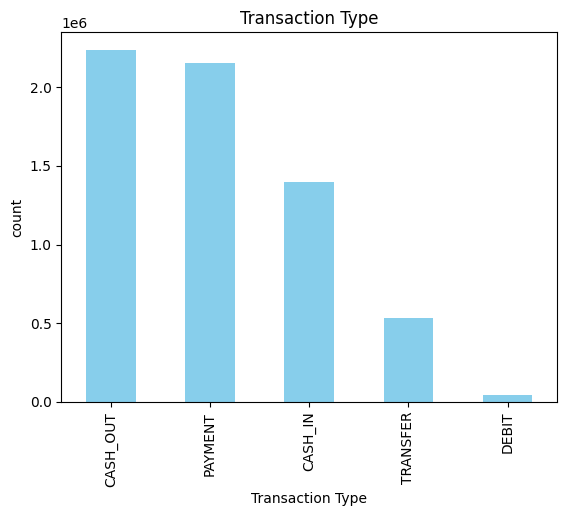

In [11]:
df['type'].value_counts().plot(kind='bar',title="Transaction Type",color='skyblue')
plt.xlabel("Transaction Type")
plt.ylabel("count")

<Axes: xlabel='type'>

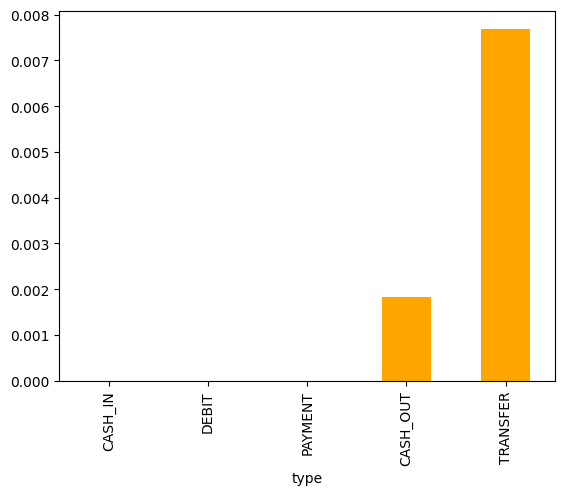

In [12]:
fraud_by_type=df.groupby("type")['isFraud'].mean().sort_values(ascending=True)
fraud_by_type.plot(kind='bar',color='orange')

In [13]:
df['amount'].describe().astype(int)

count     6362620
mean       179861
std        603858
min             0
25%         13389
50%         74871
75%        208721
max      92445516
Name: amount, dtype: int64

In [14]:
#sns.histplot(np.log1p(df['amount']),bins=100,kde=True,color='green')

In [15]:
#sns.boxplot(data=df[df['amount']<5000],x="isFraud",y="amount")

In [16]:
df.head(2)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDifferOrig,balanceDifferDest
0,1,PAYMENT,9839,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,1,PAYMENT,1864,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0


In [17]:
df['balanceDiffOrig']=df['oldbalanceOrg']-df['newbalanceOrig']
df['balanceDiffDest']=df['newbalanceDest']-df['oldbalanceDest']

In [18]:
(df['balanceDiffOrig'] <0).sum()

np.int64(1399253)

In [19]:
(df['balanceDiffDest'] <0).sum()


np.int64(1238864)

In [20]:
df.drop(columns='step',inplace=True)

In [21]:
df

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDifferOrig,balanceDifferDest,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0,9839.64,0.00,9839.64,0.00
1,PAYMENT,1864,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0,1864.28,0.00,1864.28,0.00
2,TRANSFER,181,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0,181.00,0.00,181.00,0.00
3,CASH_OUT,181,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0,181.00,-21182.00,181.00,-21182.00
4,PAYMENT,11668,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0,11668.14,0.00,11668.14,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0,339682.13,339682.13,339682.13,339682.13
6362616,TRANSFER,6311409,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0,6311409.28,0.00,6311409.28,0.00
6362617,CASH_OUT,6311409,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27,6311409.28,6311409.27
6362618,TRANSFER,850002,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0,850002.52,0.00,850002.52,0.00


In [22]:
top_recievers=df['nameDest'].value_counts().head(10)

In [23]:
top_recievers

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C1789550256     99
C451111351      99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

In [24]:
fraud_users=df[df['isFraud']==1]['nameOrig'].value_counts()
fraud_users

nameOrig
C1305486145    1
C840083671     1
C1420196421    1
C2101527076    1
C137533655     1
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 8213, dtype: int64

In [25]:
fraud_types=df[df['type'].isin(['TRANSFER','CASH_OUT'])]
fraud_types['type'].value_counts()

type
CASH_OUT    2237500
TRANSFER     532909
Name: count, dtype: int64

In [26]:
df['type'].isin(['TRANSFER','CASH_OUT']).value_counts()

type
False    3592211
True     2770409
Name: count, dtype: int64

Text(0.5, 1.0, 'Fraud Distribution in Transfer and cash_out')

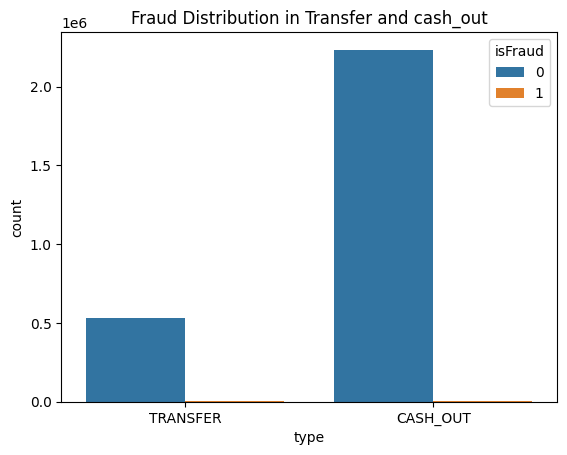

In [27]:
sns.countplot(data=fraud_types,x='type',hue='isFraud')
plt.title("Fraud Distribution in Transfer and cash_out")

In [28]:
corr=df[["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest","newbalanceDest","isFraud"]].corr()

In [29]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


<Axes: >

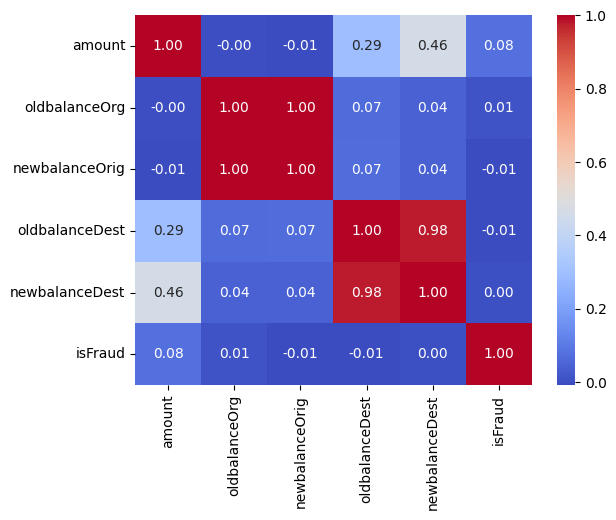

In [30]:
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')

In [31]:
zero_after_transfer=df[
(df['oldbalanceOrg']>0) &
(df['newbalanceOrig']==0) &
(df['type'].isin(['TRANSFER','CASH_OUT']))
 ]

len(zero_after_transfer)

1188074

In [32]:
zero_after_transfer

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDifferOrig,balanceDifferDest,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181,C1305486145,181.00,0.0,C553264065,0.00,0.00,1,0,181.00,0.00,181.00,0.00
3,CASH_OUT,181,C840083671,181.00,0.0,C38997010,21182.00,0.00,1,0,181.00,-21182.00,181.00,-21182.00
15,CASH_OUT,229133,C905080434,15325.00,0.0,C476402209,5083.00,51513.44,0,0,15325.00,46430.44,15325.00,46430.44
19,TRANSFER,215310,C1670993182,705.00,0.0,C1100439041,22425.00,0.00,0,0,705.00,-22425.00,705.00,-22425.00
24,TRANSFER,311685,C1984094095,10835.00,0.0,C932583850,6267.00,2719172.89,0,0,10835.00,2712905.89,10835.00,2712905.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682,C786484425,339682.13,0.0,C776919290,0.00,339682.13,1,0,339682.13,339682.13,339682.13,339682.13
6362616,TRANSFER,6311409,C1529008245,6311409.28,0.0,C1881841831,0.00,0.00,1,0,6311409.28,0.00,6311409.28,0.00
6362617,CASH_OUT,6311409,C1162922333,6311409.28,0.0,C1365125890,68488.84,6379898.11,1,0,6311409.28,6311409.27,6311409.28,6311409.27
6362618,TRANSFER,850002,C1685995037,850002.52,0.0,C2080388513,0.00,0.00,1,0,850002.52,0.00,850002.52,0.00


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [34]:
df_model=df.drop(['nameOrig','nameDest','isFlaggedFraud'],axis=1)
df_model

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDifferOrig,balanceDifferDest,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839,170136.00,160296.36,0.00,0.00,0,9839.64,0.00,9839.64,0.00
1,PAYMENT,1864,21249.00,19384.72,0.00,0.00,0,1864.28,0.00,1864.28,0.00
2,TRANSFER,181,181.00,0.00,0.00,0.00,1,181.00,0.00,181.00,0.00
3,CASH_OUT,181,181.00,0.00,21182.00,0.00,1,181.00,-21182.00,181.00,-21182.00
4,PAYMENT,11668,41554.00,29885.86,0.00,0.00,0,11668.14,0.00,11668.14,0.00
...,...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682,339682.13,0.00,0.00,339682.13,1,339682.13,339682.13,339682.13,339682.13
6362616,TRANSFER,6311409,6311409.28,0.00,0.00,0.00,1,6311409.28,0.00,6311409.28,0.00
6362617,CASH_OUT,6311409,6311409.28,0.00,68488.84,6379898.11,1,6311409.28,6311409.27,6311409.28,6311409.27
6362618,TRANSFER,850002,850002.52,0.00,0.00,0.00,1,850002.52,0.00,850002.52,0.00


In [35]:
categorical=['type']
numeric=['amount','oldbalanceOrg','newbalanceOrig','oldbalanceDest','newbalanceDest']

In [36]:
y=df_model['isFraud']
x=df_model.drop('isFraud',axis=1)
x

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,balanceDifferOrig,balanceDifferDest,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839,170136.00,160296.36,0.00,0.00,9839.64,0.00,9839.64,0.00
1,PAYMENT,1864,21249.00,19384.72,0.00,0.00,1864.28,0.00,1864.28,0.00
2,TRANSFER,181,181.00,0.00,0.00,0.00,181.00,0.00,181.00,0.00
3,CASH_OUT,181,181.00,0.00,21182.00,0.00,181.00,-21182.00,181.00,-21182.00
4,PAYMENT,11668,41554.00,29885.86,0.00,0.00,11668.14,0.00,11668.14,0.00
...,...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682,339682.13,0.00,0.00,339682.13,339682.13,339682.13,339682.13,339682.13
6362616,TRANSFER,6311409,6311409.28,0.00,0.00,0.00,6311409.28,0.00,6311409.28,0.00
6362617,CASH_OUT,6311409,6311409.28,0.00,68488.84,6379898.11,6311409.28,6311409.27,6311409.28,6311409.27
6362618,TRANSFER,850002,850002.52,0.00,0.00,0.00,850002.52,0.00,850002.52,0.00


In [37]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,stratify=y)

In [38]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric),
        ("cat",OneHotEncoder(drop="first"),categorical)
    ],
    remainder="drop"
)

In [39]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [40]:
pipeline=Pipeline([
    ('prep',preprocessor),
    ('clf',LogisticRegression(class_weight='balanced', max_iter=1000))])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [41]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

In [42]:
y_predict=pipeline.predict(X_test)
y_predict

array([0, 0, 0, ..., 0, 0, 0], shape=(1908786,))

In [43]:
print(classification_report(y_test,y_predict))


              precision    recall  f1-score   support

           0       1.00      0.95      0.97   1906322
           1       0.02      0.94      0.04      2464

    accuracy                           0.95   1908786
   macro avg       0.51      0.94      0.51   1908786
weighted avg       1.00      0.95      0.97   1908786



In [44]:
print(confusion_matrix(y_test,y_predict))


[[1804418  101904]
 [    158    2306]]


In [45]:
pipeline.score(X_test,y_test)*100

94.65304125239811

In [46]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']